# Exercise : Employee Salary Dataset

This notebook walks you through a structured exploration of an **Employee Salary Dataset**.

The dataset contains information about employees working in different departments of a company.

Columns:

- EmployeeID
- Name
- Age
- Gender
- Department
- Experience
- Salary
- PerformanceScore

---


In [2]:
# Task 1: Load the Dataset

# Import the Employee dataset into a Pandas DataFrame.

import pandas as pd

employees = pd.read_csv("./employees.csv")

# Task 2: First Look

Perform the following operations.

- Print the number of rows and columns.
- Print all column names.
- Print the first five rows.
- Print the average salary.
- Use `describe()` and explain what information it provides.


In [12]:
# Print the number of rows and columns
rows,columns = employees.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

# Print all column names
names = employees.columns.tolist()
print(names)

# Print the first five rows
employees.head()

# Print the average salary
avg_salary = employees['Salary'].mean()
print(f"Average salary: {avg_salary}")

# Use describe() and explain what information it provides
description = employees.describe()
print(description)







Number of rows: 40
Number of columns: 10
['EmployeeID', 'Name', 'Age', 'Gender', 'Department', 'Experience', 'Salary', 'PerformanceScore', 'OfficeLocation', 'ManagerRemarks']
Average salary: 73951.94594594595
       EmployeeID        Age  Experience         Salary  PerformanceScore
count   40.000000  35.000000   40.000000      37.000000         40.000000
mean    20.500000  40.685714   17.775000   73951.945946         78.375000
std     11.690452  11.806707   10.783386   24821.286542         11.790234
min      1.000000  22.000000    1.000000   36934.000000         60.000000
25%     10.750000  30.000000    7.000000   50713.000000         67.750000
50%     20.500000  42.000000   16.000000   69760.000000         77.000000
75%     30.250000  50.000000   27.250000   95637.000000         88.250000
max     40.000000  59.000000   35.000000  117719.000000         98.000000


# Task 3: Data Cleaning

Clean the dataset.

- Find which columns contain missing values.
- Replace missing values in the **Age** column using the average age.
- Drop columns with more than **40%** missing values.
- Remove all remaining rows containing missing values.
- Compare the dataset before and after cleaning.


In [17]:
# Store original shape
before_rows, before_cols = employees.shape

# Find missing values
print(employees.isnull().sum())

# Replace missing ages
employees["Age"] = employees["Age"].fillna(employees["Age"].mean())

# Remove columns with more than 40% missing values
threshold = len(employees) * 0.4
employees = employees.dropna(axis=1, thresh=threshold)

# Remove remaining rows with missing values
employees = employees.dropna()

# Store new shape
after_rows, after_cols = employees.shape

print(f"Before Cleaning : {before_rows} rows, {before_cols} columns")
print(f"After Cleaning  : {after_rows} rows, {after_cols} columns")

print("\nExplanation:")
print("- Columns with more than 40% missing values were removed.")
print("- Remaining rows containing missing values were deleted.")
print("- Missing values in the Age column were replaced using the mean age.")

EmployeeID          0
Name                0
Age                 0
Gender              0
Department          0
Experience          0
Salary              0
PerformanceScore    0
OfficeLocation      0
dtype: int64
Before Cleaning : 32 rows, 9 columns
After Cleaning  : 32 rows, 9 columns

Explanation:
- Columns with more than 40% missing values were removed.
- Remaining rows containing missing values were deleted.
- Missing values in the Age column were replaced using the mean age.


# Task 4: Exploratory Filtering

Answer the following questions.

- Did the employee with the highest salary have the highest performance score?
- Print the name of the oldest employee.
- Group employees by **Department** and calculate:
  - Average Salary
  - Average Age
  - Average Performance Score


In [19]:
# Employee with the highest salary
highest_salary_employee = employees.loc[employees["Salary"].idxmax()]

if highest_salary_employee["PerformanceScore"] == employees["PerformanceScore"].max():
    print("Yes, the employee with the highest salary also has the highest performance score.")
else:
    print("No, the employee with the highest salary does not have the highest performance score.")

# Name of the oldest employee
oldest_employee = employees.loc[employees["Age"].idxmax()]
print("Oldest Employee:", oldest_employee["Name"])

# Average Salary, Age and Performance Score by Department
result = employees.groupby("Department").agg({
    "Salary": "mean",
    "Age": "mean",
    "PerformanceScore": "mean"
})

print(result)

No, the employee with the highest salary does not have the highest performance score.
Oldest Employee: Olivia
                   Salary        Age  PerformanceScore
Department                                            
Finance      53728.800000  47.800000         76.000000
HR           81791.875000  45.250000         81.625000
IT          104836.000000  35.750000         76.250000
Marketing    80708.333333  35.666667         74.500000
Sales        67759.444444  39.000000         80.555556


# Task 5: Data Visualization

Group employees by:

- Gender
- Department

Calculate the average salary for each subgroup.

Create a **Seaborn bar plot** showing:

- X-axis → Department
- Y-axis → Average Salary
- Hue → Gender

Add:

- Title
- X-axis label
- Y-axis label

Display the graph.


   Gender Department         Salary
0  Female    Finance   48688.500000
1  Female         HR   97024.000000
2  Female         IT   94614.000000
3  Female  Marketing   79057.333333
4  Female      Sales   63502.000000
5    Male    Finance   57089.000000
6    Male         HR   72652.600000
7    Male         IT  115058.000000
8    Male  Marketing   82359.333333
9    Male      Sales   68975.857143


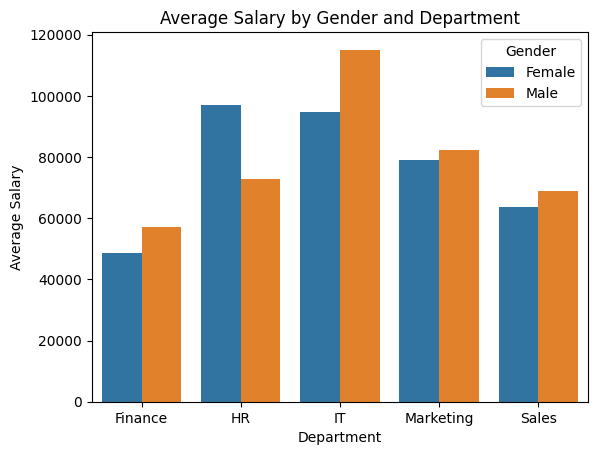

In [20]:
# Group employees by Gender and Department and calculate average salary
grouped = employees.groupby(["Gender", "Department"])["Salary"].mean().reset_index()

print(grouped)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=grouped, x="Department", y="Salary", hue="Gender")

plt.title("Average Salary by Gender and Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.show()

# Task 6: Data Interpretation

Answer the following questions.

1. Does gender appear to influence average salary?

2. Does department appear to influence salary?

3. Why is a bar chart appropriate for this analysis?

4. Could replacing missing ages with the mean introduce bias into the analysis? Explain your answer.


## Question 1: Does gender appear to influence average salary?

### Answer

Based on the bar chart, there are differences in the average salary between male and female employees in some departments. However, we cannot conclude that gender alone determines salary because other factors, such as years of experience, job role, department, and performance score, may also influence employee salaries.

Therefore, gender may appear to influence average salary in this dataset, but additional analysis would be required to determine whether gender is the actual cause of the salary differences.

---

## Question 2: Does department appear to influence salary?

### Answer

Yes. The average salary varies across different departments. Some departments have a higher average salary than others, indicating that the department is an important factor affecting employee salary.

The differences may exist because each department requires different skills, responsibilities, levels of experience, or job roles.

---

## Question 3: Why is a bar chart appropriate for this analysis?

### Answer

A bar chart is the most suitable visualization because it is designed to compare numerical values across different categories.

In this analysis:

- The categories are **Department** and **Gender**.
- The numerical value being compared is the **Average Salary**.

The bar chart makes it easy to compare salaries between departments as well as between male and female employees within each department. This allows patterns and differences to be identified quickly.

---

## Question 4: Could replacing missing ages with the mean introduce bias into the analysis? Explain your answer.

### Answer

Yes. Replacing missing ages with the mean can introduce bias because the inserted values may not represent the employees' actual ages. Mean imputation reduces the natural variation in the dataset by replacing different unknown values with the same average value.

As a result, analyses involving age may become slightly less accurate because the true distribution of ages is altered. Although mean imputation is simple and commonly used, it may not always be the best approach, especially when the data contains outliers or a large number of missing values.

---

# Final Conclusion

From the analysis, it can be concluded that the **department** appears to have a noticeable influence on employee salary, while **gender** may show differences in average salary but should not be considered the only determining factor without further statistical analysis.

The bar chart is an effective visualization because it clearly compares average salaries across different categories. Additionally, although replacing missing ages with the mean helps preserve the dataset, it may introduce slight bias by reducing the natural variability of the age distribution.

Overall, this exercise demonstrates the complete data analysis workflow, including **data cleaning, grouping, visualization, and interpretation**, which are essential steps in Data Science and Machine Learning.
